### Set Up

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce
import os
import sys

In [ ]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "moral_comp_exp4" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "moral_comp_exp4"
plots_path = Path().resolve() / "../../analysis" / "moral_comp_exp4" / "moral_comp_visualizations"
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")



scenarios_path: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../scenarios_inputs/cheung_variants
annotated_output_path: /Users/anna/Documents/code/graph_extract/analysis/cheung_variants/../../annotated_outputs/cheung_variants


In [28]:
ROOT_DIR = Path().resolve() / '/../../'
sys.path.append(ROOT_DIR)
sys.path.append(ROOT_DIR / 'src/')


In [63]:
import plot_helper
import src.generic_analysis_utils as generic_analysis_utils

### Define Functions

In [ ]:
def create_df(narrative_name, n_ids):
    """Loops through all scenario IDs for a given narrative. Loads both action choices for each scenario.
      Output a dataframe with counterfactual utility and deontology labels and annotated value."""

    rows = []

    for scenario_id in range(1, n_ids + 1):

            # read in original scenario json 
            this_scenario_file = narrative_name+".json"
            this_scenario = generic_analysis_utils.read_input_scenario(scenarios_path /  this_scenario_file, scenario_id)

            #extract the conditions from the scenario json
            scenario_text = this_scenario['text']
            scenario_deontology = this_scenario['deontology_level']
            scenario_utility = this_scenario['utility_level']
            

            #read in annotation for action choice 1
            this_annot_filename_1 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 1)
            nodes_1 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_1)

            #get the action choice
            act_choice_1 = generic_analysis_utils.extract_action(nodes_1)

            #get utility 
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_1)
            util_mean_1 = np.mean(util_df.mean())

            #get deontology
            deont_1 = generic_analysis_utils.extract_deontology(nodes_1)

            #read in annotation for action choice 2
            this_annot_filename_2 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 2)
            nodes_2 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_2)

            #get the action choice
            act_choice_2 = generic_analysis_utils.extract_action(nodes_2)

            #get utility 
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_2)
            util_mean_2 = np.mean(util_df.mean())

            #get deontology
            deont_2 = generic_analysis_utils.extract_deontology(nodes_2)


            #compute counterfactual utility
            util_diff = util_mean_1 -  util_mean_2


          
            #output stores the scenario level properties and the annotated deontology of the action 1, 
            #alongside the utility difference between action 1 and action 2.
            rows.append(
                {
                    "scenario_id": scenario_id,
                    "narrative": narrative_name,
                    "deontology_label": scenario_deontology,
                    "utility_label": scenario_utility,
                    "deontology_rating": deont_1,
                    "utility_diff": util_diff,        
                }
            )

    results_df = pd.DataFrame(rows)
    results_df.sort_values(by="scenario_id", inplace=True)
    # Ensure numeric columns are numeric just in case
    results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
    results_df["utility_diff"] = pd.to_numeric(results_df["utility_diff"], errors="coerce")

    return results_df

In [46]:
def analyze_one_scenario(narrative_name, scenario_id):


    # read in original scenario json 
    this_scenario_file = narrative_name+".json"
    this_scenario = generic_analysis_utils.read_input_scenario(scenarios_path /  this_scenario_file, scenario_id)

    #extract the conditions from the scenario json
    scenario_text = this_scenario['text']
    scenario_deontology = this_scenario['deontology_level']
    scenario_utility = this_scenario['utility_level']

    print('\ndeontology label: ' + scenario_deontology)
    print('\nutility label: ' + scenario_utility)
    
    #read in annotation for action choice 1
    this_annot_filename_1 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 1)
    nodes_1 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_1)

    #get the action choice
    act_choice_1 = generic_analysis_utils.extract_action(nodes_1)
    print('\naction choice 1: ' + act_choice_1)

    #get utility for action choice 1
    util_df_1 =  generic_analysis_utils.events_to_utility_df(nodes_1)

    #print the column means for the utility dataframe (per entity)
    print('\nutility by entity:')
    print(util_df_1.mean())

    util_mean_1 = np.mean(util_df_1.mean())
    print('\noverall utility mean: ' + str(util_mean_1))

    #get deontology
    deont_1 = generic_analysis_utils.extract_deontology(nodes_1)
    print('\ndeontology rating: ' + str(deont_1))

    #read in annotation for action choice 2
    this_annot_filename_2 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 2)
    nodes_2 = generic_analysis_utils.read_annotation(annotated_output_path / this_annot_filename_2)

    act_choice_2 = generic_analysis_utils.extract_action(nodes_2)
    print('\naction choice 2: ' + act_choice_2)

    #get utility 
    util_df_2 =  generic_analysis_utils.events_to_utility_df(nodes_2)

    print('\nutility by entity:')
    print(util_df_2.mean())

    util_mean_2 = np.mean(util_df_2.mean())
    print('\noverall utility mean: ' + str(util_mean_2))

    #get deontology
    deont_2 = generic_analysis_utils.extract_deontology(nodes_2)
    print('\ndeontology rating: ' + str(deont_2))


    #compute counterfactual utility
    util_diff = util_mean_1 -  util_mean_2



    print('\n\nutility difference between choice 1 and choice 2: ' + str(util_diff))


## Analyze Scenarios

In [45]:
#settings for narrative and file template

NARRATIVE_NAME = "lifeboat"
FILENAME_TEMPLATE = "%s_%d_choice_%d.json"


#important note, for these scenarios, we assume that there are 2 action ids, where id 1 is the action and id 2 is the counterfactual action. 

Print out the utilities in detail for a single scenario (two action choices)

In [50]:
analyze_one_scenario(NARRATIVE_NAME, 1)


deontology label: 1

utility label: 3

action choice 1: physically throw 10 passengers from lifeboat B overboard

utility by entity:
i                                                            -0.714286
10 passengers in lifeboat b who would be thrown overboard   -64.714286
the other occupants of lifeboat a                           -27.857143
51 remaining occupants of lifeboat b                         -1.428571
dtype: float64

overall utility mean: -23.678571428571427

deontology rating: -61.0

action choice 2: do nothing

utility by entity:
i                                                     -20.00
the other crew members and passengers in lifeboat a    -2.50
i, the captain in lifeboat a                          -13.75
61 passengers and crew members in lifeboat b          -69.00
dtype: float64

overall utility mean: -26.3125

deontology rating: -61.0


utility difference between choice 1 and choice 2: 2.633928571428573


Create one big dataframe for all scenarios in this narrative

In [51]:
results_df = create_df(NARRATIVE_NAME, 9)
results_df.sort_values(by="deontology_label", inplace=True)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_diff
0,1,lifeboat,1,3,-61.0,2.633929
3,4,lifeboat,1,2,-61.0,24.547619
6,7,lifeboat,1,1,-61.0,47.809524
1,2,lifeboat,2,3,-59.0,48.083333
4,5,lifeboat,2,2,-59.0,48.466667
7,8,lifeboat,2,1,-59.0,19.125000
2,3,lifeboat,3,3,-37.0,22.938889
5,6,lifeboat,3,2,-37.0,14.703704
8,9,lifeboat,3,1,-37.0,-7.190476


In [53]:
# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_diff_mean=("utility_diff", "mean"),
        utility_diff_se=("utility_diff", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_diff_mean=("utility_diff", "mean"),
        utility_diff_se=("utility_diff", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


In [54]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_diff_mean,utility_diff_se
0,1,3,-61.0,0.0,24.997024,13.043007
1,2,3,-59.0,0.0,38.558333,9.717297
2,3,3,-37.0,0.0,10.150705,8.990588


In [55]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_diff_mean,utility_diff_se
0,1,3,-52.333333,7.688375,19.914683,15.882041
1,2,3,-52.333333,7.688375,29.239330,10.024861
2,3,3,-52.333333,7.688375,24.552050,13.144883


In [59]:
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_diff
0,1,lifeboat,1,3,-61.0,2.633929
3,4,lifeboat,1,2,-61.0,24.547619
6,7,lifeboat,1,1,-61.0,47.809524
1,2,lifeboat,2,3,-59.0,48.083333
4,5,lifeboat,2,2,-59.0,48.466667
7,8,lifeboat,2,1,-59.0,19.125000
2,3,lifeboat,3,3,-37.0,22.938889
5,6,lifeboat,3,2,-37.0,14.703704
8,9,lifeboat,3,1,-37.0,-7.190476


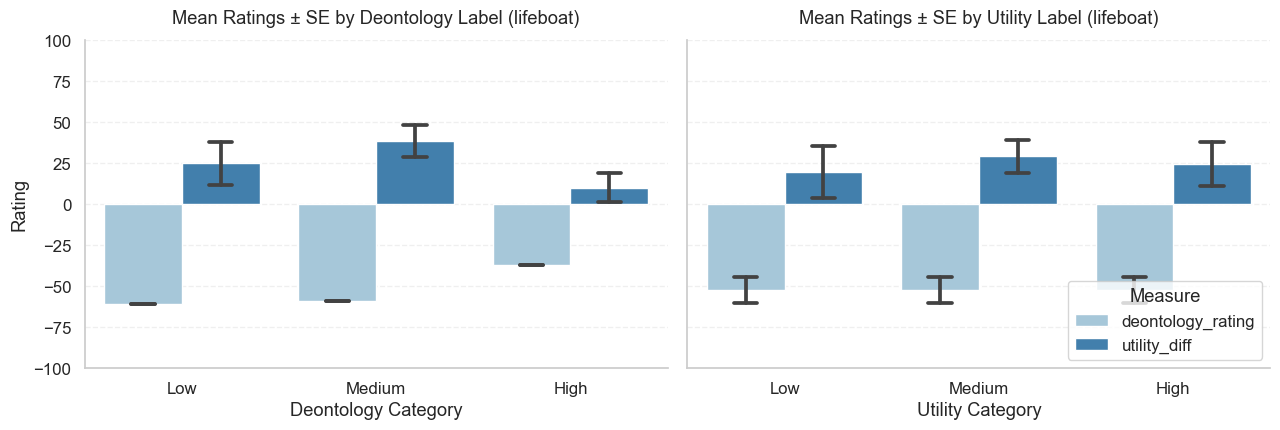

In [ ]:
## get plot

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_diff"],
    var_name="measure",
    value_name="value",
)
# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)
plot_helper.make_deont_util_plot(NARRATIVE_NAME, plot_df, plots_path)